# N04 — Deep Learning
Notebook de deep learning para pronosticar USD/UYU (usd_dlog) en 1m/3m/6m/12m.

## 0) Imports y configuración

Carga librerías, fija seeds y define parámetros globales (horizontes, lookback, splits, entrenamiento) y rutas de salida.

In [ ]:
import os, re, time, warnings, random, psutil, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

DATE_COL = "Fecha"
TARGET_COL = "usd_dlog"

# Horizontes (días hábiles aprox.)
HORIZONS = {"1m":21, "3m":63, "6m":126, "12m":252}
LOOKBACK = 30

TRAIN_FRAC = 0.7
VAL_FRAC = 0.15

EPOCHS_MAX = 80
PATIENCE = 10
N_ITER = 12


# Outputs
BASE_DIR = Path.cwd()
BASE_SAVE_DIR = BASE_DIR / "results_n05"
OOS_DIR = BASE_SAVE_DIR / "oos"
PLOTS_DIR = BASE_SAVE_DIR / "plots"
for d in [BASE_SAVE_DIR, OOS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Output:", BASE_SAVE_DIR)

# Carpeta de artefactos (modelos + preprocesamiento) para producción
ARTIFACTS_DIR = BASE_SAVE_DIR / "artifacts_dl"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Carpeta estándar (nivel proyecto) para que N07 cargue artefactos sin tocar rutas internas
PROD_ARTIFACTS_DIR = Path("artifacts_dl")
PROD_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


Output: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n05_walkforward


## 1) Carga de datos (short/long + nivel)

Lee los datasets diarios ya transformados (corto y largo plazo), normaliza la columna de fecha y carga (si existe) la serie en nivel para métricas de reconstrucción.

In [2]:
# Datasets (mismos que ML)
df_short = pd.read_excel(BASE_DIR / "results_n02" / "df_st_daily_short_plazo.xlsx")
df_long  = pd.read_excel(BASE_DIR / "results_n02" / "df_st_daily_long_plazo.xlsx")

for df in [df_short, df_long]:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df.dropna(subset=[DATE_COL], inplace=True)
    df.sort_values(DATE_COL, inplace=True)
    df.reset_index(drop=True, inplace=True)

def get_df(tag):
    return df_short if tag in ["1m","3m"] else df_long

# Serie en NIVEL para reconstrucción (pesos por dólar)
df_level = pd.read_excel(BASE_DIR / "results_n00" / "df_daily.xlsx")
df_level["Fecha"] = pd.to_datetime(df_level["Fecha"], errors="coerce")
df_level.dropna(subset=["Fecha"], inplace=True)
df_level.sort_values("Fecha", inplace=True)
df_level = df_level.drop_duplicates("Fecha").reset_index(drop=True)

# Check mínimo
if "dolar" not in df_level.columns:
    raise ValueError("df_daily.xlsx debe tener columna 'dolar' para reconstruir nivel (pesos por dólar).")

display(df_short.head())
display(df_long.head())
display(df_level.head())

,Fecha,usd_dlog,EPU_br,dolar_mexico,exp_madera,exp_carne,derivados_financieros,IMESI,imp_EU,exp_brl,...,dolar_peru,DXY_index,dolar_nueva_zelanda,NFCI,adq_neta_act_financieros,tasa_desempleo_usa,exp_agr_y_gan,WTI,emision,TPM_br
0,2015-04-01,-0.000778,317.27,15.01,17637,168829,13.08,2897.44,101741.7,102668.5,...,0.07,-0.17,0.00,0.0,-16.4,5.4,48915,2.40,1230.59,0.0
1,2015-04-06,-0.002727,317.27,14.92,17637,168829,13.08,2897.44,101741.7,102668.5,...,-0.01,-1.08,-0.01,0.0,-16.4,5.4,48915,1.96,284.39,0.0
2,2015-04-07,0.005059,317.27,14.91,17637,168829,13.08,2897.44,101741.7,102668.5,...,0.02,0.72,0.00,0.0,-16.4,5.4,48915,1.87,-323.78,0.0
3,2015-04-08,0.008889,317.27,15.08,17637,168829,13.08,2897.44,101741.7,102668.5,...,0.00,0.24,-0.01,0.0,-16.4,5.4,48915,-3.51,-103.78,0.0
4,2015-04-09,0.006902,317.27,15.22,17637,168829,13.08,2897.44,101741.7,102668.5,...,0.00,1.09,0.00,0.0,-16.4,5.4,48915,0.35,72.81,0.0


,Fecha,usd_dlog,tasa_dolares_familias,derivados_financieros,exp_arg,exp_carne,dolar_mexico,exp_quimicos,EPU_br,VIX,...,precio_oro,TPM_br,act_ext_BCU,IPC_usa,IPC_br,dep_plazo_MN,SP500,FedFunds,IPC,tasa_pesos_empresas
0,2015-04-01,-0.000778,7.3,13.08,33631.3,168829,15.01,39065,317.27,15.11,...,25.0,0.0,0.0,0.24,0.0,0.0,-8.20,0.01,0.0,0.0
1,2015-04-06,-0.002727,7.3,13.08,33631.3,168829,14.92,39065,317.27,14.74,...,10.5,0.0,0.0,0.00,0.0,0.0,20.93,0.00,0.0,0.0
2,2015-04-07,0.005059,7.3,13.08,33631.3,168829,14.91,39065,317.27,14.78,...,-8.0,0.0,0.0,0.00,0.0,0.0,-4.29,0.00,0.0,0.0
3,2015-04-08,0.008889,7.3,13.08,33631.3,168829,15.08,39065,317.27,13.98,...,-7.5,0.0,0.0,0.00,0.0,0.0,5.57,0.00,0.0,0.0
4,2015-04-09,0.006902,7.3,13.08,33631.3,168829,15.22,39065,317.27,13.09,...,-9.5,0.0,0.0,0.00,0.0,0.0,9.28,0.00,0.0,0.0


,Fecha,compras_ANCAP,int_ANCAP,var_stock_pet,inv_ANCAP,venta_autos,saldo_cuenta_corriente,ingreso_primario,inversion_directa,inversion_de_cartera,...,dolar_japon,dolar_euro,dolar_libra,dolar_suiza,dolar_canada,dolar_australia,dolar_nueva_zelanda,dolar_sudafrica,DXY_index,usd_dlog
0,2015-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,120.43,0.84,0.65,1.01,1.18,1.24,1.30,11.73,91.38,0.006231
1,2015-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,118.67,0.84,0.66,1.01,1.18,1.24,1.29,11.72,91.89,0.003307
2,2015-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,119.29,0.84,0.66,1.01,1.18,1.24,1.29,11.69,92.37,0.005351
3,2015-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,119.79,0.85,0.66,1.02,1.18,1.23,1.28,11.58,91.94,0.004097
4,2015-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,118.21,0.84,0.66,1.01,1.18,1.22,1.27,11.47,91.98,0.004894


## 2) Helpers (secuencias, splits, nivel, métricas)

Define funciones auxiliares: armado de secuencias X/y por horizonte, split temporal train/val/test, reconstrucción a nivel y métricas (retornos y nivel).

In [3]:
def sanitize_model_name(name: str) -> str:
    """Normaliza nombres para usarlos en archivos y merges (consistente con N05)."""
    return re.sub(r'[^A-Za-z0-9_]+', '', name.replace(" ", "_"))

**Qué hace esta celda:** ejecuta `def rmse(y_true, y_pred):` y prepara/actualiza los objetos necesarios para el flujo del notebook.

In [4]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def future_sum(series: pd.Series, H: int) -> pd.Series:
    # y(t) = sum_{j=1..H} r_{t+j}
    return series.shift(-1).rolling(H).sum().shift(-(H-1))

INCLUDE_TARGET_HISTORY = True  # toggle

def build_sequences(df: pd.DataFrame, H: int):
    if TARGET_COL not in df.columns:
        raise ValueError(f"No existe target {TARGET_COL} en dataset.")

    y = future_sum(df[TARGET_COL], H)

    if INCLUDE_TARGET_HISTORY:
        feat_cols = [c for c in df.columns if c != DATE_COL]   # incluye TARGET_COL
    else:
        feat_cols = [c for c in df.columns if c not in [DATE_COL, TARGET_COL]]

    X_raw = df[feat_cols].astype(float)

    X_list, y_list, dt_list = [], [], []
    for t in range(LOOKBACK - 1, len(df)):
        if pd.isna(y.iloc[t]):
            continue
        window = X_raw.iloc[t - LOOKBACK + 1 : t + 1]
        if window.isna().any().any():
            continue
        X_list.append(window.values)
        y_list.append(float(y.iloc[t]))
        dt_list.append(df[DATE_COL].iloc[t])

    X = np.array(X_list, dtype=float)
    y = np.array(y_list, dtype=float)
    dts = pd.to_datetime(pd.Series(dt_list)).reset_index(drop=True)
    return X, y, dts

def temporal_split(n: int):
    i1 = int(n * TRAIN_FRAC)
    i2 = int(n * (TRAIN_FRAC + VAL_FRAC))
    # seguridad
    i1 = max(i1, 1)
    i2 = max(i2, i1+1)
    i2 = min(i2, n-1)
    return i1, i2

def reconstruct_level(oos_df: pd.DataFrame, H: int) -> pd.DataFrame:
    """Reconstruye predicción en NIVEL (USD/UYU) a partir de y_pred (suma de log-retornos).
    Devuelve un DF estándar para producción:
    fecha, fecha_objetivo, dolar_t, dolar_pred_tH, dolar_real_tH
    """
    tmp = oos_df.copy()
    tmp["Fecha"] = pd.to_datetime(tmp["Fecha"], errors="coerce")

    if df_level is None:
        raise RuntimeError("No está cargada la serie en nivel (df_level). Necesaria para reconstruir a nivel.")

    mapH = df_level.copy()
    mapH["Fecha_objetivo"] = mapH["Fecha"].shift(-H)
    mapH["dolar_real_tH"] = mapH["dolar"].shift(-H)
    mapH = mapH[["Fecha", "dolar", "Fecha_objetivo", "dolar_real_tH"]]

    out = tmp.merge(mapH, on="Fecha", how="left")

    # Reconstrucción: S_tH = S_t * exp(sum_{j=1..H} r_{t+j})
    out["dolar_pred_tH"] = out["dolar"] * np.exp(out["y_pred"])

    out = out.dropna(subset=["Fecha_objetivo", "dolar", "dolar_real_tH", "dolar_pred_tH"]).reset_index(drop=True)

    out = out.rename(columns={
        "Fecha": "fecha",
        "Fecha_objetivo": "fecha_objetivo",
        "dolar": "dolar_t"
    })

    return out[["fecha", "fecha_objetivo", "dolar_t", "dolar_pred_tH", "dolar_real_tH"]]

def level_metrics(lvl: pd.DataFrame):
    err = (lvl["dolar_objetivo_obs"] - lvl["dolar_objetivo_pred"]).astype(float)
    mae_lvl = float(np.mean(np.abs(err)))
    rmse_lvl = float(np.sqrt(np.mean(err**2)))
    return mae_lvl, rmse_lvl

## 3) Arquitecturas (8 modelos)

Define las 8 arquitecturas en Keras (RNN/CNN/Atención) y sus builders para entrenar con la misma interfaz.

In [5]:
class SimpleAttention(layers.Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],), initializer="zeros", trainable=True)
        self.u = self.add_weight(shape=(input_shape[-1], 1), initializer="glorot_uniform", trainable=True)

    def call(self, x):
        v = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(tf.tensordot(v, self.u, axes=1), axis=1)
        return tf.reduce_sum(x * a, axis=1)

def build_lstm_model(input_shape, units, dropout, lr):
    inp = layers.Input(shape=input_shape)
    x = layers.LSTM(units, dropout=dropout)(inp)
    out = layers.Dense(1)(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr), loss="mae")
    return m

def build_gru_model(input_shape, units, dropout, lr):
    inp = layers.Input(shape=input_shape)
    x = layers.GRU(units, dropout=dropout)(inp)
    out = layers.Dense(1)(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr), loss="mae")
    return m

def build_cnn_lstm_model(input_shape, units, dropout, lr):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 3, padding="causal", activation="relu")(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(units, dropout=dropout)(x)
    out = layers.Dense(1)(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr), loss="mae")
    return m

def build_cnn_gru_model(input_shape, units, dropout, lr):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 3, padding="causal", activation="relu")(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.GRU(units, dropout=dropout)(x)
    out = layers.Dense(1)(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr), loss="mae")
    return m

def build_attn_lstm_model(input_shape, units, dropout, lr):
    inp = layers.Input(shape=input_shape)
    x = layers.LSTM(units, return_sequences=True, dropout=dropout)(inp)
    x = SimpleAttention()(x)
    out = layers.Dense(1)(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr), loss="mae")
    return m

def build_attn_gru_model(input_shape, units, dropout, lr):
    inp = layers.Input(shape=input_shape)
    x = layers.GRU(units, return_sequences=True, dropout=dropout)(inp)
    x = SimpleAttention()(x)
    out = layers.Dense(1)(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr), loss="mae")
    return m

def build_cnn_attn_lstm_model(input_shape, units, dropout, lr):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 3, padding="causal", activation="relu")(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(units, return_sequences=True, dropout=dropout)(x)
    x = SimpleAttention()(x)
    out = layers.Dense(1)(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr), loss="mae")
    return m

def build_cnn_attn_gru_model(input_shape, units, dropout, lr):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 3, padding="causal", activation="relu")(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.GRU(units, return_sequences=True, dropout=dropout)(x)
    x = SimpleAttention()(x)
    out = layers.Dense(1)(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr), loss="mae")
    return m

## 5) Random Search

Implementa un random search simple para seleccionar hiperparámetros (units, dropout, learning rate, batch) usando el set de validación.

In [6]:
def random_search(builder, X_train, y_train, X_val, y_val):
    best_val = np.inf
    best_model = None
    best_params = None

    for _ in range(N_ITER):
        units = random.choice([32, 64, 96, 128])
        dropout = random.choice([0.0, 0.1, 0.2, 0.3])
        lr = random.choice([5e-4, 1e-3, 2e-3])

        model = builder(X_train.shape[1:], units, dropout, lr)
        es = callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)

        hist = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS_MAX,
            batch_size=64,
            verbose=0,
            callbacks=[es]
        )

        val_loss = float(np.min(hist.history["val_loss"]))
        if val_loss < best_val:
            best_val = val_loss
            best_model = model
            best_params = {"units": units, "dropout": dropout, "lr": lr}

    if best_model is None:
        raise RuntimeError("Random search no produjo modelo.")
    return best_model, best_val, best_params

## 6) Runner común (devuelve tabla estilo ML + guarda OOS nivel + plot)

Entrena cada arquitectura por horizonte, guarda predicciones out-of-sample en nivel y gráficos, y devuelve una tabla de resultados con el mismo formato que tus notebooks de ML.

In [7]:
def run_model(model_name: str, builder, family: str = "DL"):
    """Entrena y evalúa un modelo DL por horizonte.

    ✅ Versión WALK-FORWARD (expanding window) por defecto:
    - Se elige 1 set de hiperparámetros con random search usando el tramo inicial (train/val).
    - Luego se hace recursive forecasting OOS con ventana expansiva:
        para cada fecha t en el tramo OOS, se re-entrena (desde cero) con los datos disponibles hasta t-1,
        usando los mismos hiperparámetros, y se predice en t.

    Notas de diseño (para que sea ejecutable y consistente con N04):
    - Para aliviar costo, se puede setear STEP_OOS_DL > 1 (p.ej. 5 o 10).
    - El scaler se ajusta SOLO con el sub-tramo de entrenamiento de cada iteración, y se aplica a val + test_t.

    Salidas por (h_tag, model):
    - OOS estándar en NIVEL: oos_{h_tag}_{model_safe}.csv/.xlsx con columnas:
      fecha, fecha_objetivo, dolar_t, dolar_pred_tH, dolar_real_tH
    - Artefactos: ARTIFACTS_DIR/{h_tag}/{model_safe}/
      model.keras, scaler.joblib, features.json, params.json, metadata.json
    """

    rows = []

    # -------------------------
    # Controles para WALK-FORWARD
    # -------------------------
    STEP_OOS_DL = globals().get("STEP_OOS_DL", 5)          # cada cuántas observaciones OOS recalibrar/pred
    MIN_TRAIN_SEQ = globals().get("MIN_TRAIN_SEQ", 250)   # mínimo de secuencias para entrenar en cada iteración
    EPOCHS_WF_MAX = globals().get("EPOCHS_WF_MAX", 60)    # epochs máx por iteración (early stopping corta)
    PATIENCE_WF  = globals().get("PATIENCE_WF", 8)        # paciencia early stopping en walk-forward

    for h_tag, H in HORIZONS.items():
        print(f"\nModelo: {model_name} | Horizonte: {h_tag}")

        df = get_df(h_tag)
        X, y, dts = build_sequences(df, H)
        n = len(y)
        if n < 300:
            raise RuntimeError(f"Pocas secuencias para {model_name}@{h_tag}: n={n}")

        # split base para elegir hiperparámetros (una sola vez)
        i1, i2 = temporal_split(n)   # train_end=i1, val_end=i2, test_start=i2
        if i2 < MIN_TRAIN_SEQ:
            raise RuntimeError(f"Tramo inicial muy corto para walk-forward: i2={i2}, MIN_TRAIN_SEQ={MIN_TRAIN_SEQ}")

        # =========================
        # 1) Selección de hiperparámetros en tramo inicial (train/val)
        # =========================
        scaler0 = StandardScaler()
        n_feat = X.shape[-1]

        def scale3d_with(scaler, A, fit=False):
            A2 = A.reshape(-1, n_feat)
            A2 = scaler.fit_transform(A2) if fit else scaler.transform(A2)
            return A2.reshape(A.shape)

        X_train0, y_train0 = X[:i1], y[:i1]
        X_val0,   y_val0   = X[i1:i2], y[i1:i2]

        X_train0_s = scale3d_with(scaler0, X_train0, fit=True)
        X_val0_s   = scale3d_with(scaler0, X_val0,   fit=False)

        t0 = time.perf_counter()
        model0, best_val, best_params = random_search(builder, X_train0_s, y_train0, X_val0_s, y_val0)
        t1 = time.perf_counter()

        print(f"Best params ({h_tag}): {best_params} | best val_loss={best_val:.6f} | search_min={(t1-t0)/60:.2f}")

        # =========================
        # 2) WALK-FORWARD OOS (expanding window)
        # =========================
        # tramo OOS: desde i2 hasta n-1
        oos_dates = []
        y_true_list = []
        y_pred_list = []

        # helper fit/predict por iteración
        def fit_one_iteration(X_all, y_all):
            # split interno: último VAL_FRAC del train como validación
            m = len(y_all)
            val_size = max(30, int(m * VAL_FRAC))
            val_size = min(val_size, max(1, m-1))
            tr_end = m - val_size

            X_tr, y_tr = X_all[:tr_end], y_all[:tr_end]
            X_va, y_va = X_all[tr_end:], y_all[tr_end:]

            # scaler por iteración (fit solo con X_tr)
            scaler = StandardScaler()
            X_tr_s = scale3d_with(scaler, X_tr, fit=True)
            X_va_s = scale3d_with(scaler, X_va, fit=False)

            # entrenar desde cero con best_params
            model = builder(X_tr_s.shape[1:], best_params["units"], best_params["dropout"], best_params["lr"])
            es = callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE_WF, restore_best_weights=True)

            model.fit(
                X_tr_s, y_tr,
                validation_data=(X_va_s, y_va),
                epochs=EPOCHS_WF_MAX,
                batch_size=64,
                verbose=0,
                callbacks=[es]
            )
            return model, scaler

        t2 = time.perf_counter()
        n_oos_steps = 0

        for i in range(i2, n, STEP_OOS_DL):
            # expanding: entreno con todo hasta i-1
            X_hist = X[:i]
            y_hist = y[:i]

            if len(y_hist) < MIN_TRAIN_SEQ:
                continue

            model_i, scaler_i = fit_one_iteration(X_hist, y_hist)

            # predicción en i (una observación)
            X_i = X[i:i+1]
            X_i_s = scale3d_with(scaler_i, X_i, fit=False)
            pred = float(model_i.predict(X_i_s, verbose=0).reshape(-1)[0])

            oos_dates.append(dts.iloc[i])
            y_true_list.append(float(y[i]))
            y_pred_list.append(pred)
            n_oos_steps += 1

            # limpieza básica para RAM/VRAM
            try:
                tf.keras.backend.clear_session()
            except Exception:
                pass

        t3 = time.perf_counter()
        if n_oos_steps < 10:
            raise RuntimeError(f"Muy pocas predicciones OOS en walk-forward: {n_oos_steps}. Revisa STEP_OOS_DL o splits.")

        # =========================
        # 3) Métricas en retornos (sobre puntos OOS evaluados)
        # =========================
        y_true_arr = np.array(y_true_list, dtype=float)
        y_pred_arr = np.array(y_pred_list, dtype=float)

        mae = float(mean_absolute_error(y_true_arr, y_pred_arr))
        rmse_v = float(np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)))
        r2 = float(r2_score(y_true_arr, y_pred_arr))

        # =========================
        # 4) Reconstrucción a NIVEL + métricas en nivel
        # =========================
        oos = pd.DataFrame({"Fecha": pd.to_datetime(oos_dates), "y_true": y_true_arr, "y_pred": y_pred_arr})
        lvl = reconstruct_level(oos, H)

        mae_lvl = float(mean_absolute_error(lvl["dolar_real_tH"], lvl["dolar_pred_tH"]))
        rmse_lvl = float(np.sqrt(mean_squared_error(lvl["dolar_real_tH"], lvl["dolar_pred_tH"])))
        r2_lvl = float(r2_score(lvl["dolar_real_tH"], lvl["dolar_pred_tH"]))

        # =========================
        # 5) Guardados (OOS + artefactos)
        # =========================
        model_safe = sanitize_model_name(model_name)

        oos_csv = OOS_DIR / f"oos_{h_tag}_{model_safe}.csv"
        oos_xlsx = OOS_DIR / f"oos_{h_tag}_{model_safe}.xlsx"
        lvl.to_csv(oos_csv, index=False)
        lvl.to_excel(oos_xlsx, index=False)

        art_dir = ARTIFACTS_DIR / h_tag / model_safe
        art_dir.mkdir(parents=True, exist_ok=True)
        art_dir_prod = PROD_ARTIFACTS_DIR / h_tag / model_safe
        art_dir_prod.mkdir(parents=True, exist_ok=True)

        # Guardar un modelo/scaler "final" entrenado con todo el tramo disponible hasta el último punto OOS usado
        # (útil para producción / replicación)
        last_i = min(n-1, i2 + (n_oos_steps-1)*STEP_OOS_DL)
        X_final = X[:last_i]
        y_final = y[:last_i]
        model_f, scaler_f = fit_one_iteration(X_final, y_final)

        try:
            model_f.save(art_dir / "model.keras", include_optimizer=False)
            model_f.save(art_dir_prod / "model.keras", include_optimizer=False)
        except Exception as e:
            print("⚠️ No pude guardar el modelo keras:", e)

        try:
            import joblib
            joblib.dump(scaler_f, art_dir / "scaler.joblib")
            joblib.dump(scaler_f, art_dir_prod / "scaler.joblib")
        except Exception as e:
            print("⚠️ No pude guardar scaler:", e)

        feat_cols = [c for c in df.columns if c not in [DATE_COL, TARGET_COL]]
        (art_dir / "features.json").write_text(json.dumps(feat_cols, ensure_ascii=False, indent=2))
        (art_dir_prod / "features.json").write_text(json.dumps(feat_cols, ensure_ascii=False, indent=2))

        (art_dir / "params.json").write_text(json.dumps(best_params, ensure_ascii=False, indent=2))
        (art_dir_prod / "params.json").write_text(json.dumps(best_params, ensure_ascii=False, indent=2))

        meta = {
            "h_tag": h_tag,
            "H_days": int(H),
            "family": family,
            "model": model_name,
            "model_safe": model_safe,
            "lookback": int(LOOKBACK),
            "target_col": TARGET_COL,
            "date_col": DATE_COL,
            "n_feat": int(len(feat_cols)),
            "walk_forward": True,
            "step_oos_dl": int(STEP_OOS_DL),
            "min_train_seq": int(MIN_TRAIN_SEQ),
            "epochs_wf_max": int(EPOCHS_WF_MAX),
            "patience_wf": int(PATIENCE_WF),
            "train_frac": float(TRAIN_FRAC),
            "val_frac": float(VAL_FRAC),
            "test_frac": float(1.0 - TRAIN_FRAC - VAL_FRAC),
            "hp_search": {"n_iter": int(N_ITER), "patience": int(PATIENCE), "epochs_max": int(EPOCHS_MAX)},
            "search_minutes": float((t1 - t0) / 60.0),
            "walkforward_minutes": float((t3 - t2) / 60.0),
            "n_total_seq": int(n),
            "n_initial_train": int(i1),
            "n_initial_val": int(i2 - i1),
            "oos_start_date": str(dts.iloc[i2].date()) if i2 < len(dts) else None,
            "oos_points": int(n_oos_steps),
        }
        (art_dir / "metadata.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2))
        (art_dir_prod / "metadata.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2))

        # =========================
        # 6) Plot de nivel (real vs pred)
        # =========================
        try:
            plt.figure(figsize=(10, 3))
            plt.plot(lvl["fecha_objetivo"], lvl["dolar_real_tH"], label="Real (nivel)")
            plt.plot(lvl["fecha_objetivo"], lvl["dolar_pred_tH"], label="Pred (nivel)")
            plt.title(f"{model_name} - {h_tag} (USD/UYU en nivel) | WF step={STEP_OOS_DL}")
            plt.legend()
            plt.tight_layout()
            plt.savefig(PLOTS_DIR / f"level_{h_tag}_{model_safe}.png", dpi=150)
            plt.show()
        except Exception as e:
            print("⚠️ Plot falló:", e)

        rows.append({
            "h_tag": h_tag,
            "H_days": int(H),
            "family": family,
            "model": model_name,
            "model_safe": model_safe,
            "MAE": mae,
            "RMSE": rmse_v,
            "R2": r2,
            "MAE_level": mae_lvl,
            "RMSE_level": rmse_lvl,
            "R2_level": r2_lvl,
            "params": json.dumps(best_params, ensure_ascii=False),
            "params_json": json.dumps(best_params, ensure_ascii=False),
            "search_min": float((t1 - t0) / 60.0),
            "oos_min": float((t3 - t2) / 60.0),
            "n_total_seq": int(n),
            "n_initial_train": int(i1),
            "n_initial_val": int(i2 - i1),
            "oos_points": int(n_oos_steps),
            "step_oos": int(STEP_OOS_DL),
            "n_level": int(len(lvl)),
        })

        print("RAM (MB):", round(psutil.Process().memory_info().rss / 1024**2, 1))

    return pd.DataFrame(rows)

## 7) MODELO: LSTM

Ejecuta el runner para LSTM en todos los horizontes y muestra la tabla resultante.


Modelo: LSTM | Horizonte: 1m
Best params (1m): {'units': 96, 'dropout': 0.1, 'lr': 0.002} | best val_loss=0.016646 | search_min=3.46



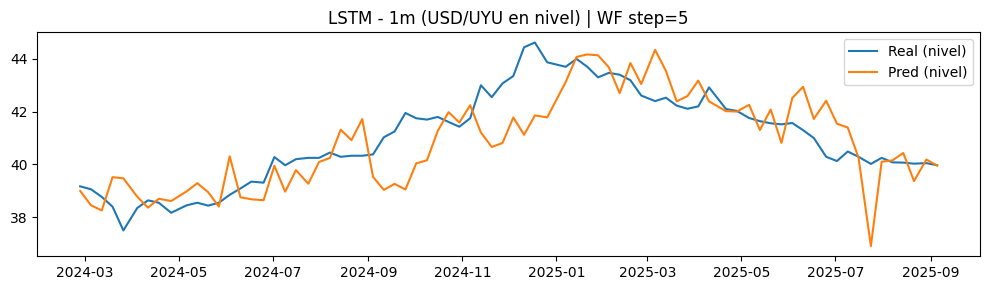

RAM (MB): 1806.8

Modelo: LSTM | Horizonte: 3m
Best params (3m): {'units': 64, 'dropout': 0.2, 'lr': 0.002} | best val_loss=0.023269 | search_min=3.45


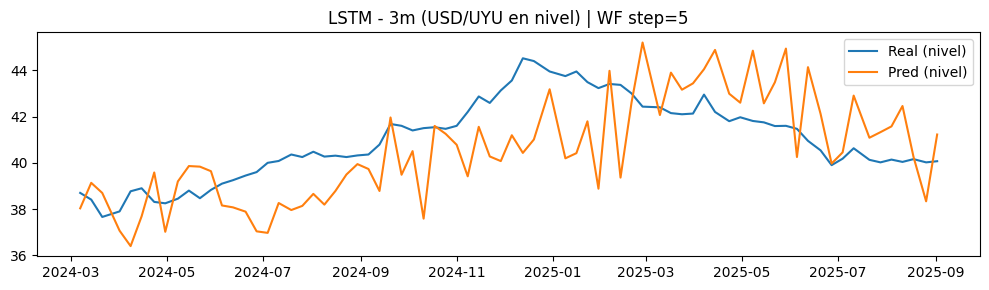

RAM (MB): 2929.4

Modelo: LSTM | Horizonte: 6m
Best params (6m): {'units': 128, 'dropout': 0.1, 'lr': 0.002} | best val_loss=0.030078 | search_min=3.70


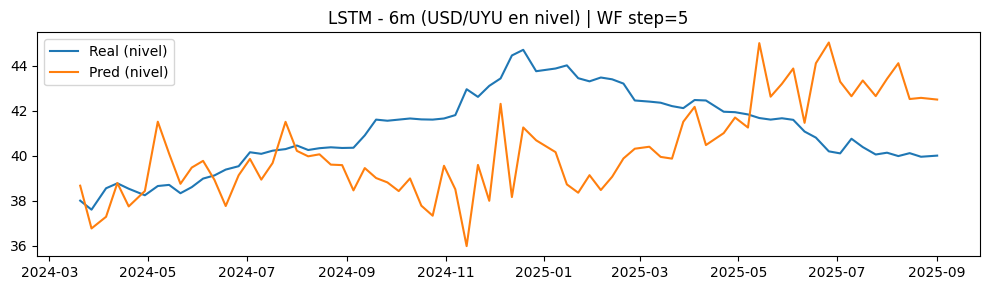

RAM (MB): 4086.9

Modelo: LSTM | Horizonte: 12m
Best params (12m): {'units': 128, 'dropout': 0.0, 'lr': 0.002} | best val_loss=0.029944 | search_min=4.07


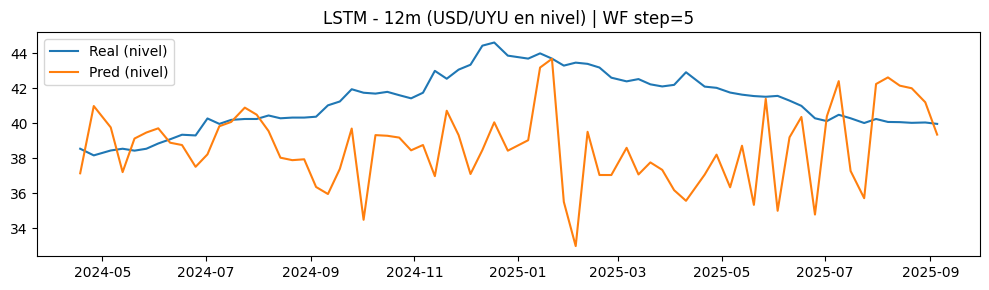

RAM (MB): 5130.0


,h_tag,H_days,family,model,model_safe,MAE,RMSE,R2,MAE_level,RMSE_level,...,params,params_json,search_min,oos_min,n_total_seq,n_initial_train,n_initial_val,oos_points,step_oos,n_level
0,1m,21,DL,LSTM,LSTM,0.021700,0.028835,-1.039289,0.890332,1.184915,...,"{""units"": 96, ""dropout"": 0.1, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.1, ""lr"": 0.002}",3.456362,19.443885,2534,1773,380,77,5,77
1,3m,63,DL,LSTM,LSTM,0.040495,0.048060,-0.380462,1.655538,1.974083,...,"{""units"": 64, ""dropout"": 0.2, ""lr"": 0.002}","{""units"": 64, ""dropout"": 0.2, ""lr"": 0.002}",3.448849,13.691241,2492,1744,374,75,5,75
2,6m,126,DL,LSTM,LSTM,0.054055,0.066944,-0.218394,2.212956,2.742101,...,"{""units"": 128, ""dropout"": 0.1, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.1, ""lr"": 0.002}",3.696195,20.343660,2429,1700,364,73,5,73
3,12m,252,DL,LSTM,LSTM,0.080087,0.099328,-4.592164,3.170860,3.908876,...,"{""units"": 128, ""dropout"": 0.0, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.0, ""lr"": 0.002}",4.066850,22.488808,2303,1612,345,70,5,70


In [8]:
results_lstm = run_model("LSTM", build_lstm_model)
display(results_lstm)

## 7) MODELO: GRU

Ejecuta el runner para GRU en todos los horizontes y muestra la tabla resultante.


Modelo: GRU | Horizonte: 1m
Best params (1m): {'units': 128, 'dropout': 0.2, 'lr': 0.002} | best val_loss=0.015021 | search_min=4.44


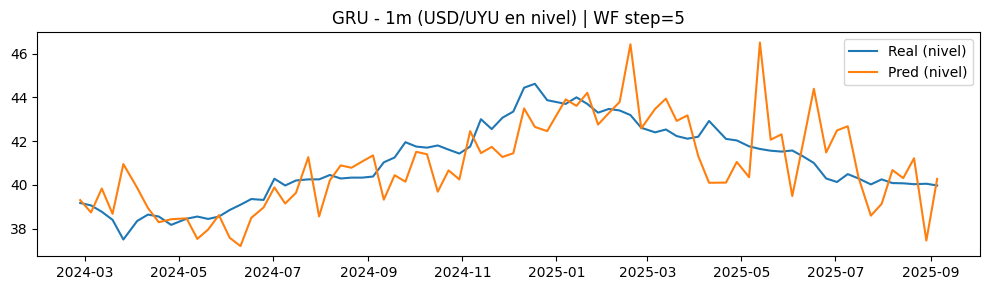

RAM (MB): 6574.0

Modelo: GRU | Horizonte: 3m
Best params (3m): {'units': 96, 'dropout': 0.2, 'lr': 0.002} | best val_loss=0.023048 | search_min=4.65


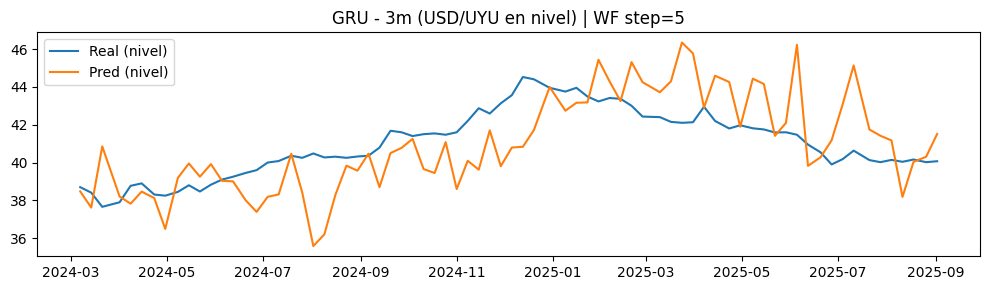

RAM (MB): 7966.2

Modelo: GRU | Horizonte: 6m
Best params (6m): {'units': 128, 'dropout': 0.1, 'lr': 0.002} | best val_loss=0.026689 | search_min=4.87


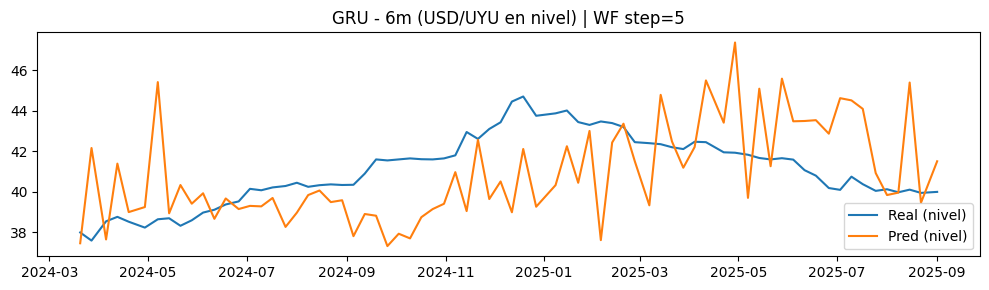

RAM (MB): 9246.1

Modelo: GRU | Horizonte: 12m
Best params (12m): {'units': 64, 'dropout': 0.1, 'lr': 0.002} | best val_loss=0.048497 | search_min=3.08


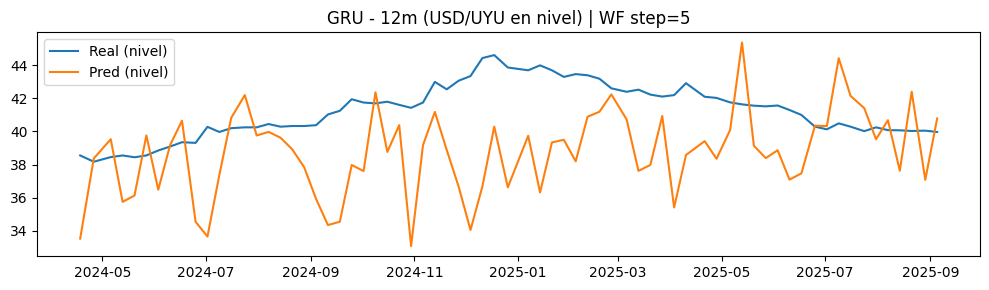

RAM (MB): 10516.2


,h_tag,H_days,family,model,model_safe,MAE,RMSE,R2,MAE_level,RMSE_level,...,params,params_json,search_min,oos_min,n_total_seq,n_initial_train,n_initial_val,oos_points,step_oos,n_level
0,1m,21,DL,GRU,GRU,0.026664,0.034464,-1.913341,1.097975,1.430343,...,"{""units"": 128, ""dropout"": 0.2, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.2, ""lr"": 0.002}",4.436341,31.998328,2534,1773,380,77,5,77
1,3m,63,DL,GRU,GRU,0.038108,0.048701,-0.417547,1.568661,2.010832,...,"{""units"": 96, ""dropout"": 0.2, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.2, ""lr"": 0.002}",4.645651,26.362413,2492,1744,374,75,5,75
2,6m,126,DL,GRU,GRU,0.050917,0.064361,-0.126199,2.103995,2.671735,...,"{""units"": 128, ""dropout"": 0.1, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.1, ""lr"": 0.002}",4.867648,26.715151,2429,1700,364,73,5,73
3,12m,252,DL,GRU,GRU,0.079184,0.098023,-4.446190,3.131369,3.842698,...,"{""units"": 64, ""dropout"": 0.1, ""lr"": 0.002}","{""units"": 64, ""dropout"": 0.1, ""lr"": 0.002}",3.083574,20.013021,2303,1612,345,70,5,70


In [9]:
results_gru = run_model("GRU", build_gru_model)
display(results_gru)

## 7) MODELO: CNN_LSTM

Ejecuta el runner para CNN+LSTM en todos los horizontes y muestra la tabla resultante.


Modelo: CNN_LSTM | Horizonte: 1m
Best params (1m): {'units': 128, 'dropout': 0.2, 'lr': 0.002} | best val_loss=0.015540 | search_min=2.40


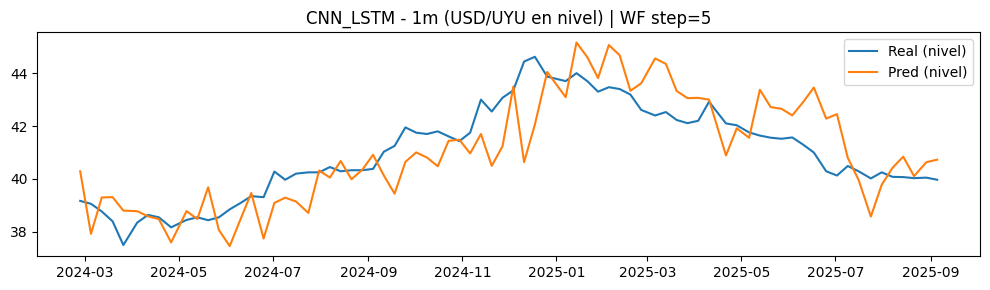

RAM (MB): 12120.5

Modelo: CNN_LSTM | Horizonte: 3m
Best params (3m): {'units': 128, 'dropout': 0.1, 'lr': 0.002} | best val_loss=0.017266 | search_min=4.21


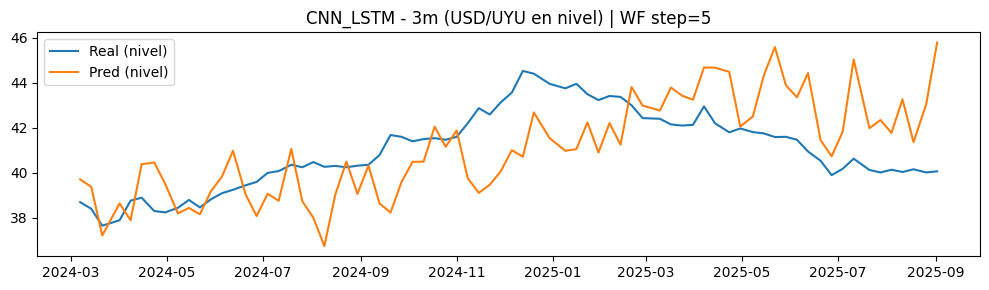

RAM (MB): 13652.7

Modelo: CNN_LSTM | Horizonte: 6m
Best params (6m): {'units': 128, 'dropout': 0.3, 'lr': 0.001} | best val_loss=0.019581 | search_min=3.87


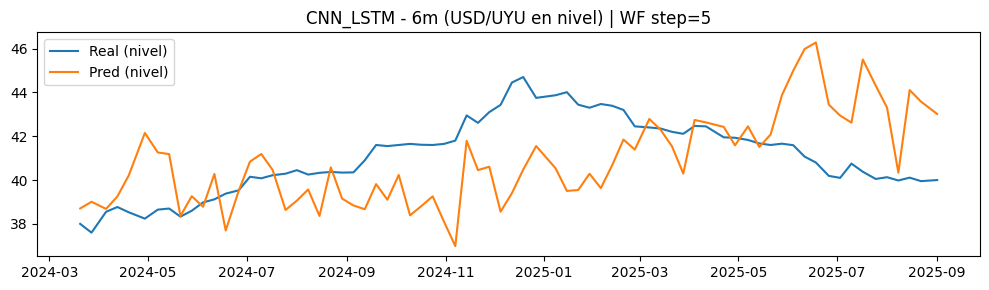

RAM (MB): 15054.8

Modelo: CNN_LSTM | Horizonte: 12m
Best params (12m): {'units': 128, 'dropout': 0.1, 'lr': 0.001} | best val_loss=0.026780 | search_min=3.44


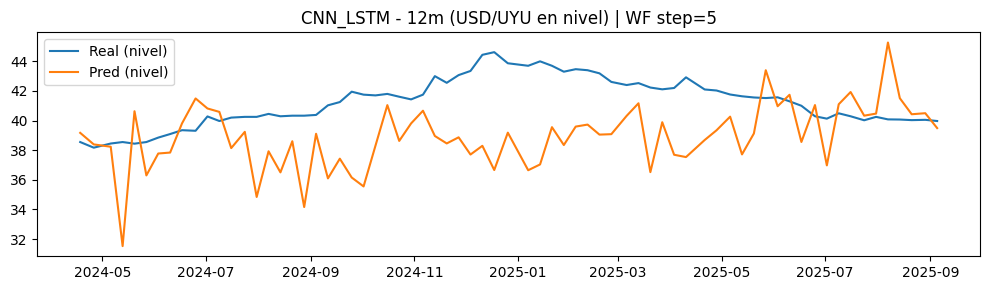

RAM (MB): 16365.7


,h_tag,H_days,family,model,model_safe,MAE,RMSE,R2,MAE_level,RMSE_level,...,params,params_json,search_min,oos_min,n_total_seq,n_initial_train,n_initial_val,oos_points,step_oos,n_level
0,1m,21,DL,CNN_LSTM,CNN_LSTM,0.022650,0.028386,-0.976287,0.935090,1.180181,...,"{""units"": 128, ""dropout"": 0.2, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.2, ""lr"": 0.002}",2.398409,23.269434,2534,1773,380,77,5,77
1,3m,63,DL,CNN_LSTM,CNN_LSTM,0.041305,0.049691,-0.475729,1.709873,2.069933,...,"{""units"": 128, ""dropout"": 0.1, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.1, ""lr"": 0.002}",4.208258,23.460099,2492,1744,374,75,5,75
2,6m,126,DL,CNN_LSTM,CNN_LSTM,0.050204,0.062053,-0.046876,2.072003,2.575171,...,"{""units"": 128, ""dropout"": 0.3, ""lr"": 0.001}","{""units"": 128, ""dropout"": 0.3, ""lr"": 0.001}",3.868998,24.190563,2429,1700,364,73,5,73
3,12m,252,DL,CNN_LSTM,CNN_LSTM,0.072989,0.090221,-3.613699,2.907796,3.574546,...,"{""units"": 128, ""dropout"": 0.1, ""lr"": 0.001}","{""units"": 128, ""dropout"": 0.1, ""lr"": 0.001}",3.436688,24.363544,2303,1612,345,70,5,70


In [10]:
results_cnn_lstm = run_model("CNN_LSTM", build_cnn_lstm_model)
display(results_cnn_lstm)

## 7) MODELO: CNN_GRU

Ejecuta el runner para CNN+GRU en todos los horizontes y muestra la tabla resultante.


Modelo: CNN_GRU | Horizonte: 1m
Best params (1m): {'units': 128, 'dropout': 0.2, 'lr': 0.0005} | best val_loss=0.015544 | search_min=2.84


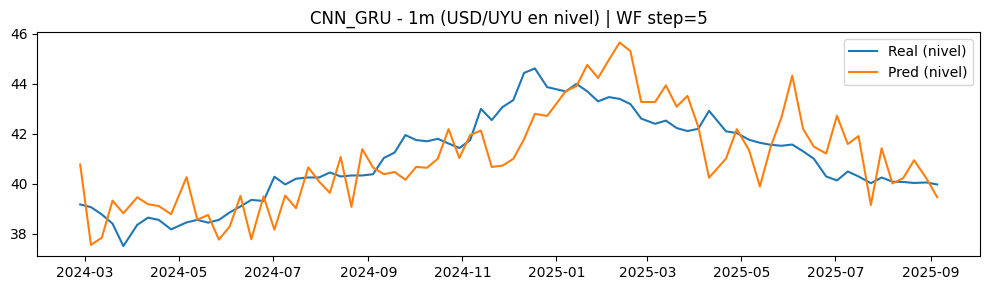

RAM (MB): 16977.8

Modelo: CNN_GRU | Horizonte: 3m
Best params (3m): {'units': 96, 'dropout': 0.3, 'lr': 0.002} | best val_loss=0.026475 | search_min=2.58


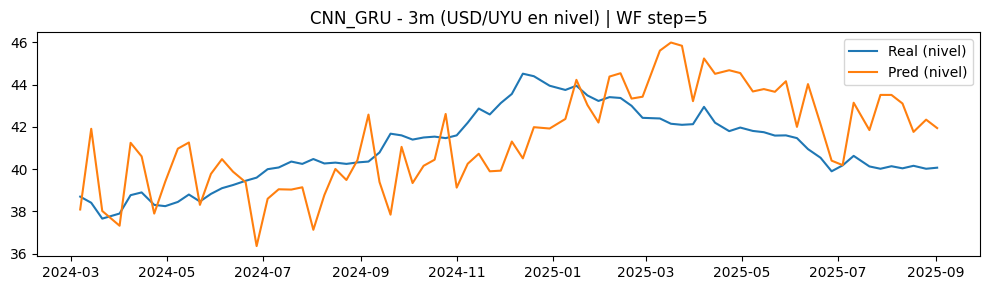

RAM (MB): 18396.4

Modelo: CNN_GRU | Horizonte: 6m
Best params (6m): {'units': 64, 'dropout': 0.2, 'lr': 0.001} | best val_loss=0.022621 | search_min=3.74


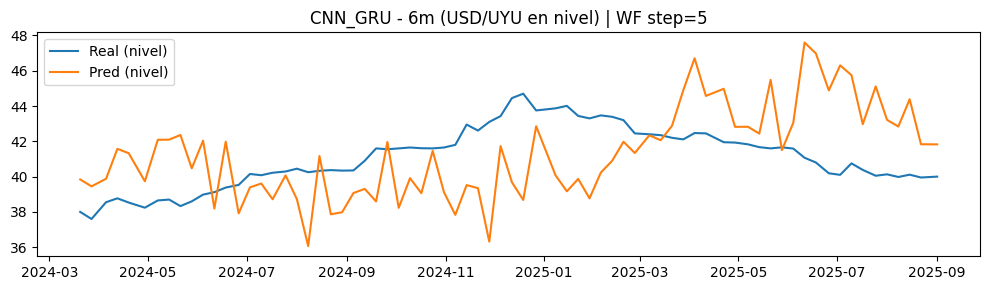

RAM (MB): 19034.9

Modelo: CNN_GRU | Horizonte: 12m
Best params (12m): {'units': 64, 'dropout': 0.3, 'lr': 0.002} | best val_loss=0.024241 | search_min=3.81


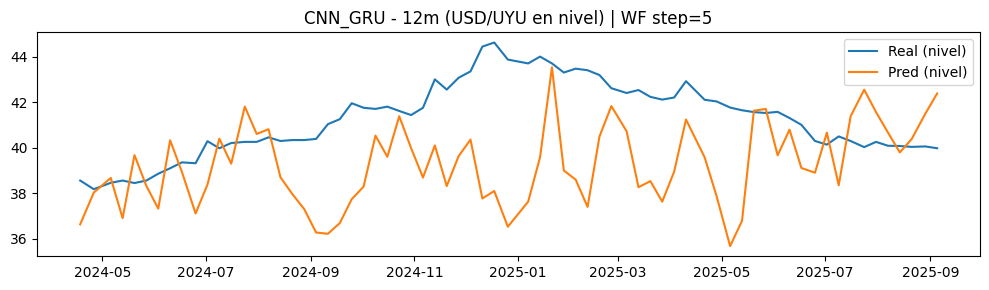

RAM (MB): 19919.5


,h_tag,H_days,family,model,model_safe,MAE,RMSE,R2,MAE_level,RMSE_level,...,params,params_json,search_min,oos_min,n_total_seq,n_initial_train,n_initial_val,oos_points,step_oos,n_level
0,1m,21,DL,CNN_GRU,CNN_GRU,0.024721,0.029910,-1.194314,1.019175,1.240859,...,"{""units"": 128, ""dropout"": 0.2, ""lr"": 0.0005}","{""units"": 128, ""dropout"": 0.2, ""lr"": 0.0005}",2.840064,34.640278,2534,1773,380,77,5,77
1,3m,63,DL,CNN_GRU,CNN_GRU,0.042694,0.049803,-0.482395,1.768670,2.067706,...,"{""units"": 96, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.3, ""lr"": 0.002}",2.580647,27.251128,2492,1744,374,75,5,75
2,6m,126,DL,CNN_GRU,CNN_GRU,0.063427,0.074718,-0.517831,2.622081,3.106690,...,"{""units"": 64, ""dropout"": 0.2, ""lr"": 0.001}","{""units"": 64, ""dropout"": 0.2, ""lr"": 0.001}",3.736469,27.883000,2429,1700,364,73,5,73
3,12m,252,DL,CNN_GRU,CNN_GRU,0.061013,0.076874,-2.349586,2.450054,3.086885,...,"{""units"": 64, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 64, ""dropout"": 0.3, ""lr"": 0.002}",3.810587,27.039238,2303,1612,345,70,5,70


In [11]:
results_cnn_gru = run_model("CNN_GRU", build_cnn_gru_model)
display(results_cnn_gru)

## 7) MODELO: ATTN_LSTM

Ejecuta el runner para Attention+LSTM en todos los horizontes y muestra la tabla resultante.


Modelo: ATTN_LSTM | Horizonte: 1m
Best params (1m): {'units': 96, 'dropout': 0.3, 'lr': 0.002} | best val_loss=0.017447 | search_min=3.86


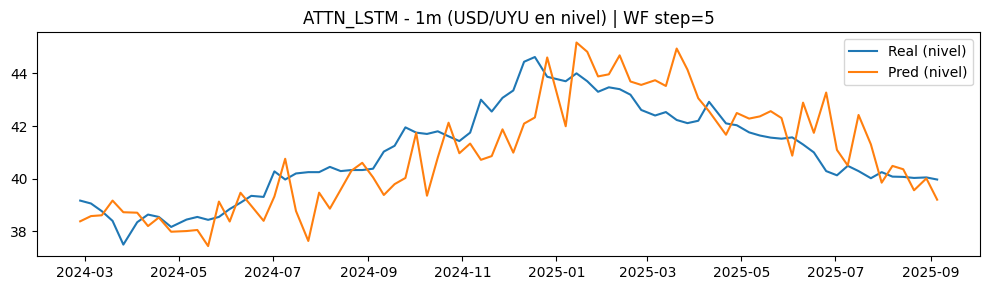

RAM (MB): 19914.2

Modelo: ATTN_LSTM | Horizonte: 3m
Best params (3m): {'units': 128, 'dropout': 0.3, 'lr': 0.002} | best val_loss=0.020508 | search_min=4.63


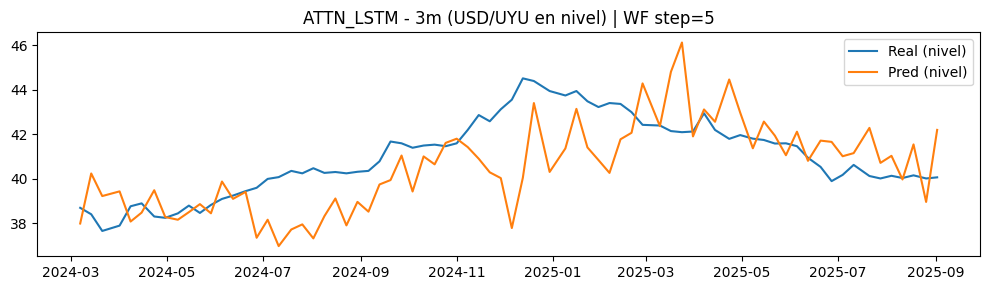

RAM (MB): 20251.4

Modelo: ATTN_LSTM | Horizonte: 6m
Best params (6m): {'units': 128, 'dropout': 0.3, 'lr': 0.002} | best val_loss=0.032538 | search_min=4.45


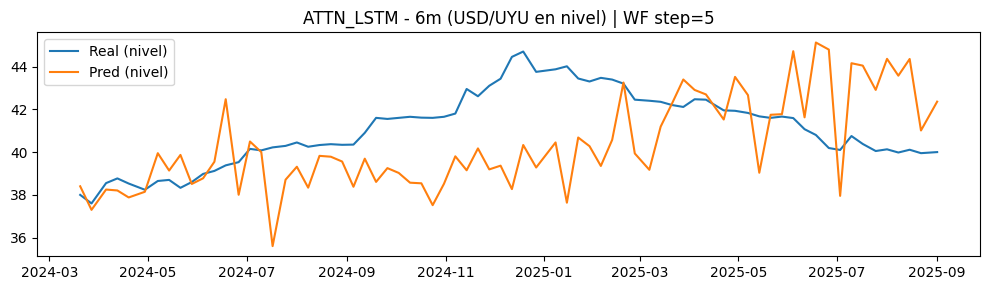

RAM (MB): 20664.0

Modelo: ATTN_LSTM | Horizonte: 12m
Best params (12m): {'units': 96, 'dropout': 0.3, 'lr': 0.002} | best val_loss=0.034993 | search_min=3.93


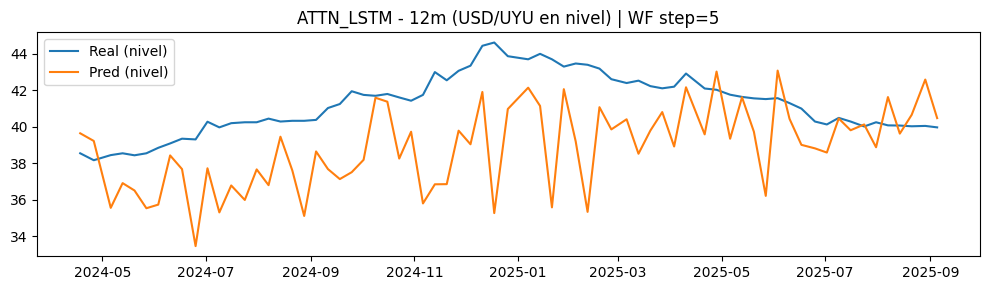

RAM (MB): 19754.6


,h_tag,H_days,family,model,model_safe,MAE,RMSE,R2,MAE_level,RMSE_level,...,params,params_json,search_min,oos_min,n_total_seq,n_initial_train,n_initial_val,oos_points,step_oos,n_level
0,1m,21,DL,ATTN_LSTM,ATTN_LSTM,0.023267,0.028829,-1.038502,0.961002,1.196777,...,"{""units"": 96, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.3, ""lr"": 0.002}",3.864618,38.629586,2534,1773,380,77,5,77
1,3m,63,DL,ATTN_LSTM,ATTN_LSTM,0.034645,0.044477,-0.182323,1.415755,1.823736,...,"{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}",4.629359,38.085363,2492,1744,374,75,5,75
2,6m,126,DL,ATTN_LSTM,ATTN_LSTM,0.051947,0.064907,-0.145393,2.129922,2.668984,...,"{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}",4.448079,34.893056,2429,1700,364,73,5,73
3,12m,252,DL,ATTN_LSTM,ATTN_LSTM,0.068034,0.084908,-3.086350,2.692689,3.340506,...,"{""units"": 96, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.3, ""lr"": 0.002}",3.931252,29.062444,2303,1612,345,70,5,70


In [12]:
results_attn_lstm = run_model("ATTN_LSTM", build_attn_lstm_model)
display(results_attn_lstm)

## 7) MODELO: ATTN_GRU

Ejecuta el runner para Attention+GRU en todos los horizontes y muestra la tabla resultante.


Modelo: ATTN_GRU | Horizonte: 1m
Best params (1m): {'units': 96, 'dropout': 0.2, 'lr': 0.002} | best val_loss=0.016307 | search_min=4.89


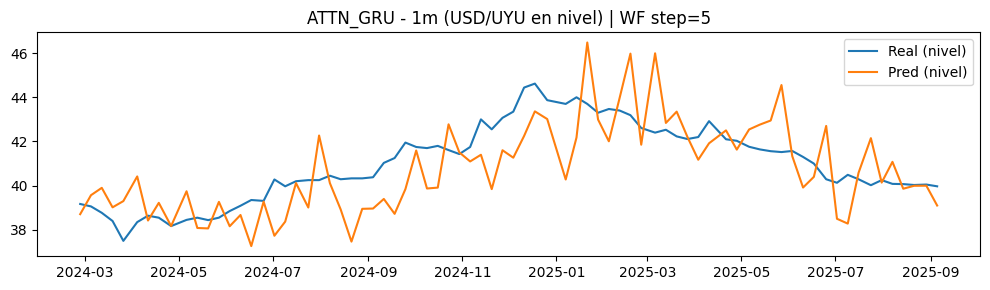

RAM (MB): 14037.1

Modelo: ATTN_GRU | Horizonte: 3m
Best params (3m): {'units': 128, 'dropout': 0.3, 'lr': 0.001} | best val_loss=0.023006 | search_min=3.56


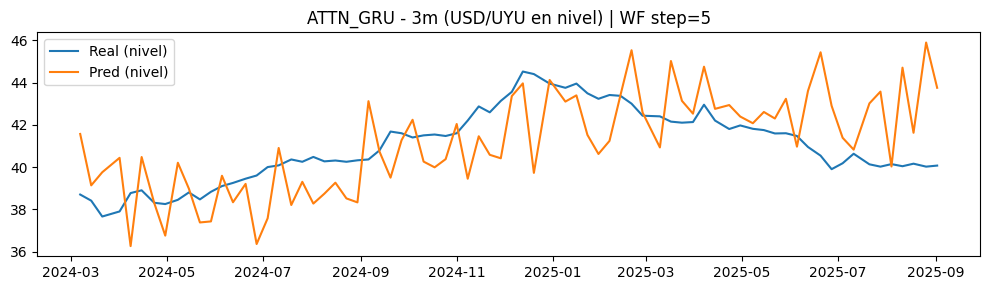

RAM (MB): 15616.6

Modelo: ATTN_GRU | Horizonte: 6m
Best params (6m): {'units': 96, 'dropout': 0.1, 'lr': 0.001} | best val_loss=0.031935 | search_min=4.03


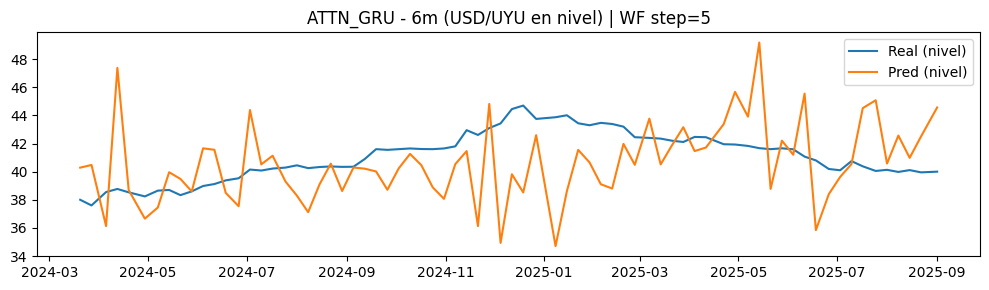

RAM (MB): 11727.4

Modelo: ATTN_GRU | Horizonte: 12m
Best params (12m): {'units': 128, 'dropout': 0.3, 'lr': 0.002} | best val_loss=0.036839 | search_min=3.49


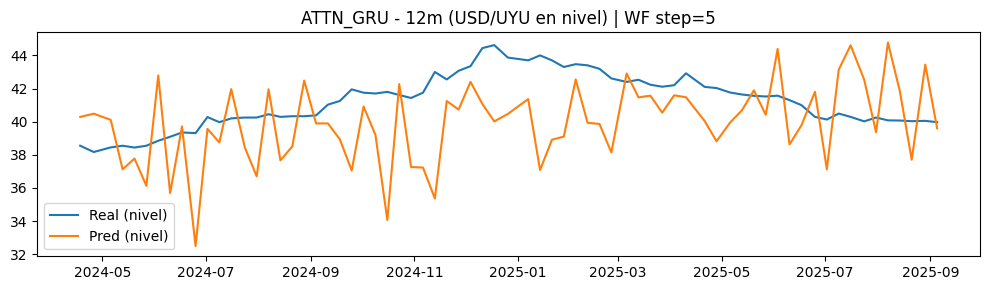

RAM (MB): 13686.5


,h_tag,H_days,family,model,model_safe,MAE,RMSE,R2,MAE_level,RMSE_level,...,params,params_json,search_min,oos_min,n_total_seq,n_initial_train,n_initial_val,oos_points,step_oos,n_level
0,1m,21,DL,ATTN_GRU,ATTN_GRU,0.029690,0.036766,-2.315519,1.220307,1.518778,...,"{""units"": 96, ""dropout"": 0.2, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.2, ""lr"": 0.002}",4.893705,46.480724,2534,1773,380,77,5,77
1,3m,63,DL,ATTN_GRU,ATTN_GRU,0.039436,0.049603,-0.470511,1.619501,2.050275,...,"{""units"": 128, ""dropout"": 0.3, ""lr"": 0.001}","{""units"": 128, ""dropout"": 0.3, ""lr"": 0.001}",3.562161,45.011138,2492,1744,374,75,5,75
2,6m,126,DL,ATTN_GRU,ATTN_GRU,0.059729,0.078825,-0.689255,2.445184,3.229543,...,"{""units"": 96, ""dropout"": 0.1, ""lr"": 0.001}","{""units"": 96, ""dropout"": 0.1, ""lr"": 0.001}",4.033319,53.227201,2429,1700,364,73,5,73
3,12m,252,DL,ATTN_GRU,ATTN_GRU,0.062044,0.076292,-2.299049,2.494349,3.034874,...,"{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}",3.493196,37.840705,2303,1612,345,70,5,70


In [13]:
results_attn_gru = run_model("ATTN_GRU", build_attn_gru_model)
display(results_attn_gru)

## 8) Consolidado final (formato ML + exportes)

Consolida resultados de los 8 modelos, calcula el mejor por horizonte según métricas en nivel y exporta tablas finales en Excel.

In [15]:
# Unir todas las tablas por modelo
results_all = pd.concat([
    results_lstm,
    results_gru,
    results_cnn_lstm,
    results_cnn_gru,
    results_attn_lstm,
    results_attn_gru,
]).reset_index(drop=True)

# EXACTO como ML: orden + dedup + sort
results_df = (
    results_all
    .drop_duplicates(subset=["h_tag","model"], keep="last")
    .sort_values(["h_tag","MAE","model"])
    .reset_index(drop=True)
)

display(results_df)

# Exportes estilo ML
results_df.to_excel(BASE_SAVE_DIR / "fx_results_dl.xlsx", index=False)
results_df.to_csv(BASE_SAVE_DIR / "fx_results_dl.csv", index=False)

# Best por horizonte (por nivel)
best_df = (
    results_df.sort_values(["h_tag","MAE_level","model"])
    .groupby("h_tag", as_index=False)
    .head(1)
    .reset_index(drop=True)
)
best_df.to_excel(BASE_SAVE_DIR / "fx_best_model_by_horizon_dl.xlsx", index=False)
best_df.to_csv(BASE_SAVE_DIR / "fx_best_model_by_horizon_dl.csv", index=False)

display(best_df)

print("✅ Exportes guardados en:", BASE_SAVE_DIR)
print(" - fx_results_dl.xlsx")
print(" - fx_best_model_by_horizon_dl.xlsx")
print(" - OOS nivel: ", OOS_DIR)
print(" - Plots nivel: ", PLOTS_DIR)

,h_tag,H_days,family,model,model_safe,MAE,RMSE,R2,MAE_level,RMSE_level,...,params,params_json,search_min,oos_min,n_total_seq,n_initial_train,n_initial_val,oos_points,step_oos,n_level
0,12m,252,DL,CNN_GRU,CNN_GRU,0.061013,0.076874,-2.349586,2.450054,3.086885,...,"{""units"": 64, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 64, ""dropout"": 0.3, ""lr"": 0.002}",3.810587,27.039238,2303,1612,345,70,5,70
1,12m,252,DL,ATTN_GRU,ATTN_GRU,0.062044,0.076292,-2.299049,2.494349,3.034874,...,"{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}",3.493196,37.840705,2303,1612,345,70,5,70
2,12m,252,DL,ATTN_LSTM,ATTN_LSTM,0.068034,0.084908,-3.086350,2.692689,3.340506,...,"{""units"": 96, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.3, ""lr"": 0.002}",3.931252,29.062444,2303,1612,345,70,5,70
3,12m,252,DL,CNN_LSTM,CNN_LSTM,0.072989,0.090221,-3.613699,2.907796,3.574546,...,"{""units"": 128, ""dropout"": 0.1, ""lr"": 0.001}","{""units"": 128, ""dropout"": 0.1, ""lr"": 0.001}",3.436688,24.363544,2303,1612,345,70,5,70
4,12m,252,DL,GRU,GRU,0.079184,0.098023,-4.446190,3.131369,3.842698,...,"{""units"": 64, ""dropout"": 0.1, ""lr"": 0.002}","{""units"": 64, ""dropout"": 0.1, ""lr"": 0.002}",3.083574,20.013021,2303,1612,345,70,5,70
5,12m,252,DL,LSTM,LSTM,0.080087,0.099328,-4.592164,3.170860,3.908876,...,"{""units"": 128, ""dropout"": 0.0, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.0, ""lr"": 0.002}",4.066850,22.488808,2303,1612,345,70,5,70
6,1m,21,DL,LSTM,LSTM,0.021700,0.028835,-1.039289,0.890332,1.184915,...,"{""units"": 96, ""dropout"": 0.1, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.1, ""lr"": 0.002}",3.456362,19.443885,2534,1773,380,77,5,77
7,1m,21,DL,CNN_LSTM,CNN_LSTM,0.022650,0.028386,-0.976287,0.935090,1.180181,...,"{""units"": 128, ""dropout"": 0.2, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.2, ""lr"": 0.002}",2.398409,23.269434,2534,1773,380,77,5,77
8,1m,21,DL,ATTN_LSTM,ATTN_LSTM,0.023267,0.028829,-1.038502,0.961002,1.196777,...,"{""units"": 96, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.3, ""lr"": 0.002}",3.864618,38.629586,2534,1773,380,77,5,77
9,1m,21,DL,CNN_GRU,CNN_GRU,0.024721,0.029910,-1.194314,1.019175,1.240859,...,"{""units"": 128, ""dropout"": 0.2, ""lr"": 0.0005}","{""units"": 128, ""dropout"": 0.2, ""lr"": 0.0005}",2.840064,34.640278,2534,1773,380,77,5,77


,h_tag,H_days,family,model,model_safe,MAE,RMSE,R2,MAE_level,RMSE_level,...,params,params_json,search_min,oos_min,n_total_seq,n_initial_train,n_initial_val,oos_points,step_oos,n_level
0,12m,252,DL,CNN_GRU,CNN_GRU,0.061013,0.076874,-2.349586,2.450054,3.086885,...,"{""units"": 64, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 64, ""dropout"": 0.3, ""lr"": 0.002}",3.810587,27.039238,2303,1612,345,70,5,70
1,1m,21,DL,LSTM,LSTM,0.021700,0.028835,-1.039289,0.890332,1.184915,...,"{""units"": 96, ""dropout"": 0.1, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.1, ""lr"": 0.002}",3.456362,19.443885,2534,1773,380,77,5,77
2,3m,63,DL,ATTN_LSTM,ATTN_LSTM,0.034645,0.044477,-0.182323,1.415755,1.823736,...,"{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}",4.629359,38.085363,2492,1744,374,75,5,75
3,6m,126,DL,CNN_LSTM,CNN_LSTM,0.050204,0.062053,-0.046876,2.072003,2.575171,...,"{""units"": 128, ""dropout"": 0.3, ""lr"": 0.001}","{""units"": 128, ""dropout"": 0.3, ""lr"": 0.001}",3.868998,24.190563,2429,1700,364,73,5,73


✅ Exportes guardados en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n05_walkforward
 - fx_results_dl.xlsx
 - fx_best_model_by_horizon_dl.xlsx
 - OOS nivel:  c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n05_walkforward\oos
 - Plots nivel:  c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n05_walkforward\plots


## Guardado de Artefactos para Producción
Esta sección permite guardar el modelo Deep Learning entrenado, el scaler (si aplica), las features utilizadas y sus parámetros.

In [16]:
import os
import json
import joblib
from tensorflow import keras

def save_dl_artifacts(model, scaler, features, params, h_tag, model_safe):
    base_dir = os.path.join("artifacts_dl", h_tag, model_safe)
    os.makedirs(base_dir, exist_ok=True)

    model.save(os.path.join(base_dir, "model.keras"))

    if scaler is not None:
        joblib.dump(scaler, os.path.join(base_dir, "scaler.joblib"))

    with open(os.path.join(base_dir, "features.json"), "w") as f:
        json.dump(features, f)

    with open(os.path.join(base_dir, "params.json"), "w") as f:
        json.dump(params, f)

    metadata = {
        "horizon": h_tag,
        "n_features": len(features)
    }

    with open(os.path.join(base_dir, "metadata.json"), "w") as f:
        json.dump(metadata, f)

    print(f"Artefactos DL guardados en {base_dir}")

# Para utilizar después de entrenar el modelo final:
#save_dl_artifacts(model_final, scaler, features_list, params_dict, h_tag, model_safe)
